# <img style="float: left; padding-right: 20px; width: 200px" src="https://github.com/ymotomy/ymotomy.github.io/blob/main/imagenes/UC.png?raw=true">  IMT2118 - Ciencia de Datos Geoespaciales
**Pontificia Universidad Católica de Chile**<br>
**Semestre 2025-1**<br>
**Estudiantes:** Christian Camilo | Tomás Romero <br>
---

<hr>
<h1 style="text-align:center;"> Recomendador de Localizaciones para Observatorios en Chile usando Imágenes Satelitales y Datos Raster/Vectoriales

Chile se ha consolidado como uno de los destinos más privilegiados del mundo para la observación astronómica, gracias a sus cielos despejados, baja humedad atmosférica y reducida contaminación lumínica en vastas zonas del norte del país. Sin embargo, con el crecimiento urbano, el cambio climático y el avance de la infraestructura, resulta cada vez más necesario identificar nuevos sitios potenciales que maximicen las condiciones óptimas para la instalación de observatorios astronómicos.

Este proyecto propone el desarrollo de un sistema de recomendación basado en análisis multicriterio espacial para predecir zonas favorables para la construcción de observatorios en Chile. Para ello, se utilizarán imágenes satelitales y datos geoespaciales provenientes de diversas fuentes, tales como sensores MODIS, Sentinel-5P, Landsat y DMSP-OLS, combinando información sobre contaminación lumínica, cobertura nubosa, altitud, calidad del aire, uso de suelo y proximidad a centros urbanos.

A través del uso de herramientas como Google Earth Engine y Python, se desarrollará un flujo automatizado de procesamiento y análisis que permita integrar tanto datos raster como vectoriales. El resultado será una visualización dinámica e interactiva de los sitios más idóneos, que considere tanto criterios astronómicos como restricciones territoriales.

Este estudio busca no solo aplicar técnicas avanzadas de ciencia de datos geoespaciales, sino también contribuir a la planificación estratégica de infraestructura astronómica en Chile, promoviendo el uso sustentable del territorio en armonía con el desarrollo científico.
<hr>

In [95]:
#Primero importamos algunas librerias
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import geemap,ee
import matplotlib.colors as colors
from shapely.geometry import shape, box
from matplotlib import colors
import geopandas as gpd
from shapely.geometry import Polygon
import numpy as np
import matplotlib.patches as mpatches
from shapely.geometry import MultiPolygon
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
import os

In [85]:
ee.Authenticate()
# ee.Initialize(project='ee-ccamz2')
ee.Initialize(project='ee-tomasromero')

In [86]:
# Seleccionamos rango de fechas
startDate= '2024-01-01'
endDate = '2025-01-01'

## Mapa de Chile

In [87]:
chile = gpd.read_file('Datos/Comunas/Comunas.shp').to_crs(epsg=4326)#.to_crs(epsg=32719)
chile = chile[chile['codregion'].isin([1, 2, 3, 4])]

#Quitamos isla de pascua y juan fernandez
chile = chile[~chile['Comuna'].isin(['Isla de Pascua', 'Juan Fernández'])]
chile.head(1)

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
46,66,134800.83733,5,5,4103,4,6.897651e+08,156310.933278,Región de Coquimbo,Andacollo,Elqui,"POLYGON ((-71.12438 -30.11141, -71.12418 -30.1..."


In [88]:
#Funcion dada por chatGpt para eliminar las islas y podamos plotear correctamente Chile continental
def keep_only_mainland(geom):
    if geom.geom_type == 'Polygon':
        return geom
    elif geom.geom_type == 'MultiPolygon':
        # Se queda con el polígono de mayor área
        largest = max(geom.geoms, key=lambda g: g.area)
        return largest
    else:
        return geom
# Aplicar a todas las geometrías
chile['geometry'] = chile['geometry'].apply(keep_only_mainland)
chile['aux'] = 1

In [89]:
# Arreglar geometrías inválidas antes de disolver
chile['geometry'] = chile['geometry'].buffer(0)

chile = chile.dissolve(by='aux', as_index=False)
chile = chile['geometry']

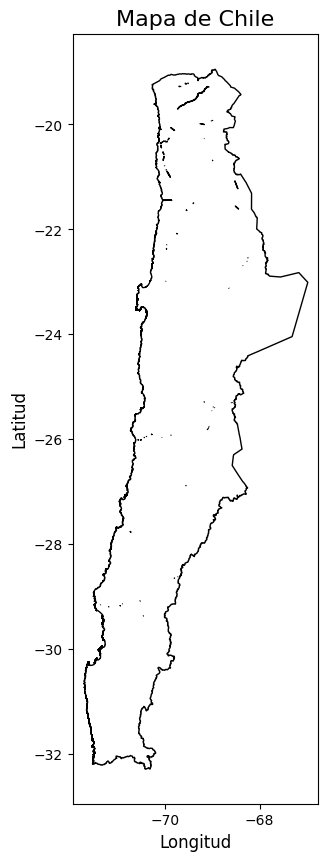

In [93]:
chile.plot(color='white', edgecolor='black', figsize=(10, 10))
# Añadir título y etiquetas
plt.title('Mapa de Chile', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.show()

## Hacer hexagonos

In [94]:
def create_hexagon(center_x, center_y, size):
    """Crea un hexágono regular centrado en (center_x, center_y) con el tamaño dado."""
    angles = np.linspace(0, 2 * np.pi, 7)
    x_hex = center_x + size * np.cos(angles)
    y_hex = center_y + size * np.sin(angles)
    return Polygon(zip(x_hex, y_hex))


In [96]:
# Tamaño del hexágono (en grados si estás en EPSG:4326)
hex_size = 0.2  # ajusta según la escala que necesites

# Obtener el bounding box de la frontera de Chile
minx, miny, maxx, maxy = chile.total_bounds

# Cálculo de la altura y ancho del hexágono
hex_height = np.sqrt(3) * hex_size
hex_width = 2 * hex_size
vert_spacing = hex_height
horiz_spacing = 3/4 * hex_width

# Generar centros de hexágonos
hexes = []
y = miny
row = 0
while y < maxy + hex_height:
    x = minx - hex_width if row % 2 else minx
    while x < maxx + hex_width:
        hex_poly = create_hexagon(x, y, hex_size)
        hexes.append(hex_poly)
        x += horiz_spacing
    y += vert_spacing
    row += 1

# Crear GeoDataFrame con los hexágonos
hex_grid = gpd.GeoDataFrame(geometry=hexes, crs=chile.crs)


In [97]:
hex_grid

,geometry
0,"POLYGON ((-71.51745 -32.28216, -71.61745 -32.1..."
1,"POLYGON ((-71.21745 -32.28216, -71.31745 -32.1..."
2,"POLYGON ((-70.91745 -32.28216, -71.01745 -32.1..."
3,"POLYGON ((-70.61745 -32.28216, -70.71745 -32.1..."
4,"POLYGON ((-70.31745 -32.28216, -70.41745 -32.1..."
...,...
735,"POLYGON ((-67.71745 -18.77216, -67.81745 -18.5..."
736,"POLYGON ((-67.41745 -18.77216, -67.51745 -18.5..."
737,"POLYGON ((-67.11745 -18.77216, -67.21745 -18.5..."
738,"POLYGON ((-66.81745 -18.77216, -66.91745 -18.5..."


## Filtrar hexagonos que esten en chile

## POR CADA SATELITE, ASIGNAR INFO CADA HEXAGONO

# MODELO